# Examples from pre-trained dataset imagenet1k

### ResNet (careful for the last max pooling layer)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.705042].


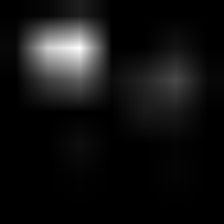

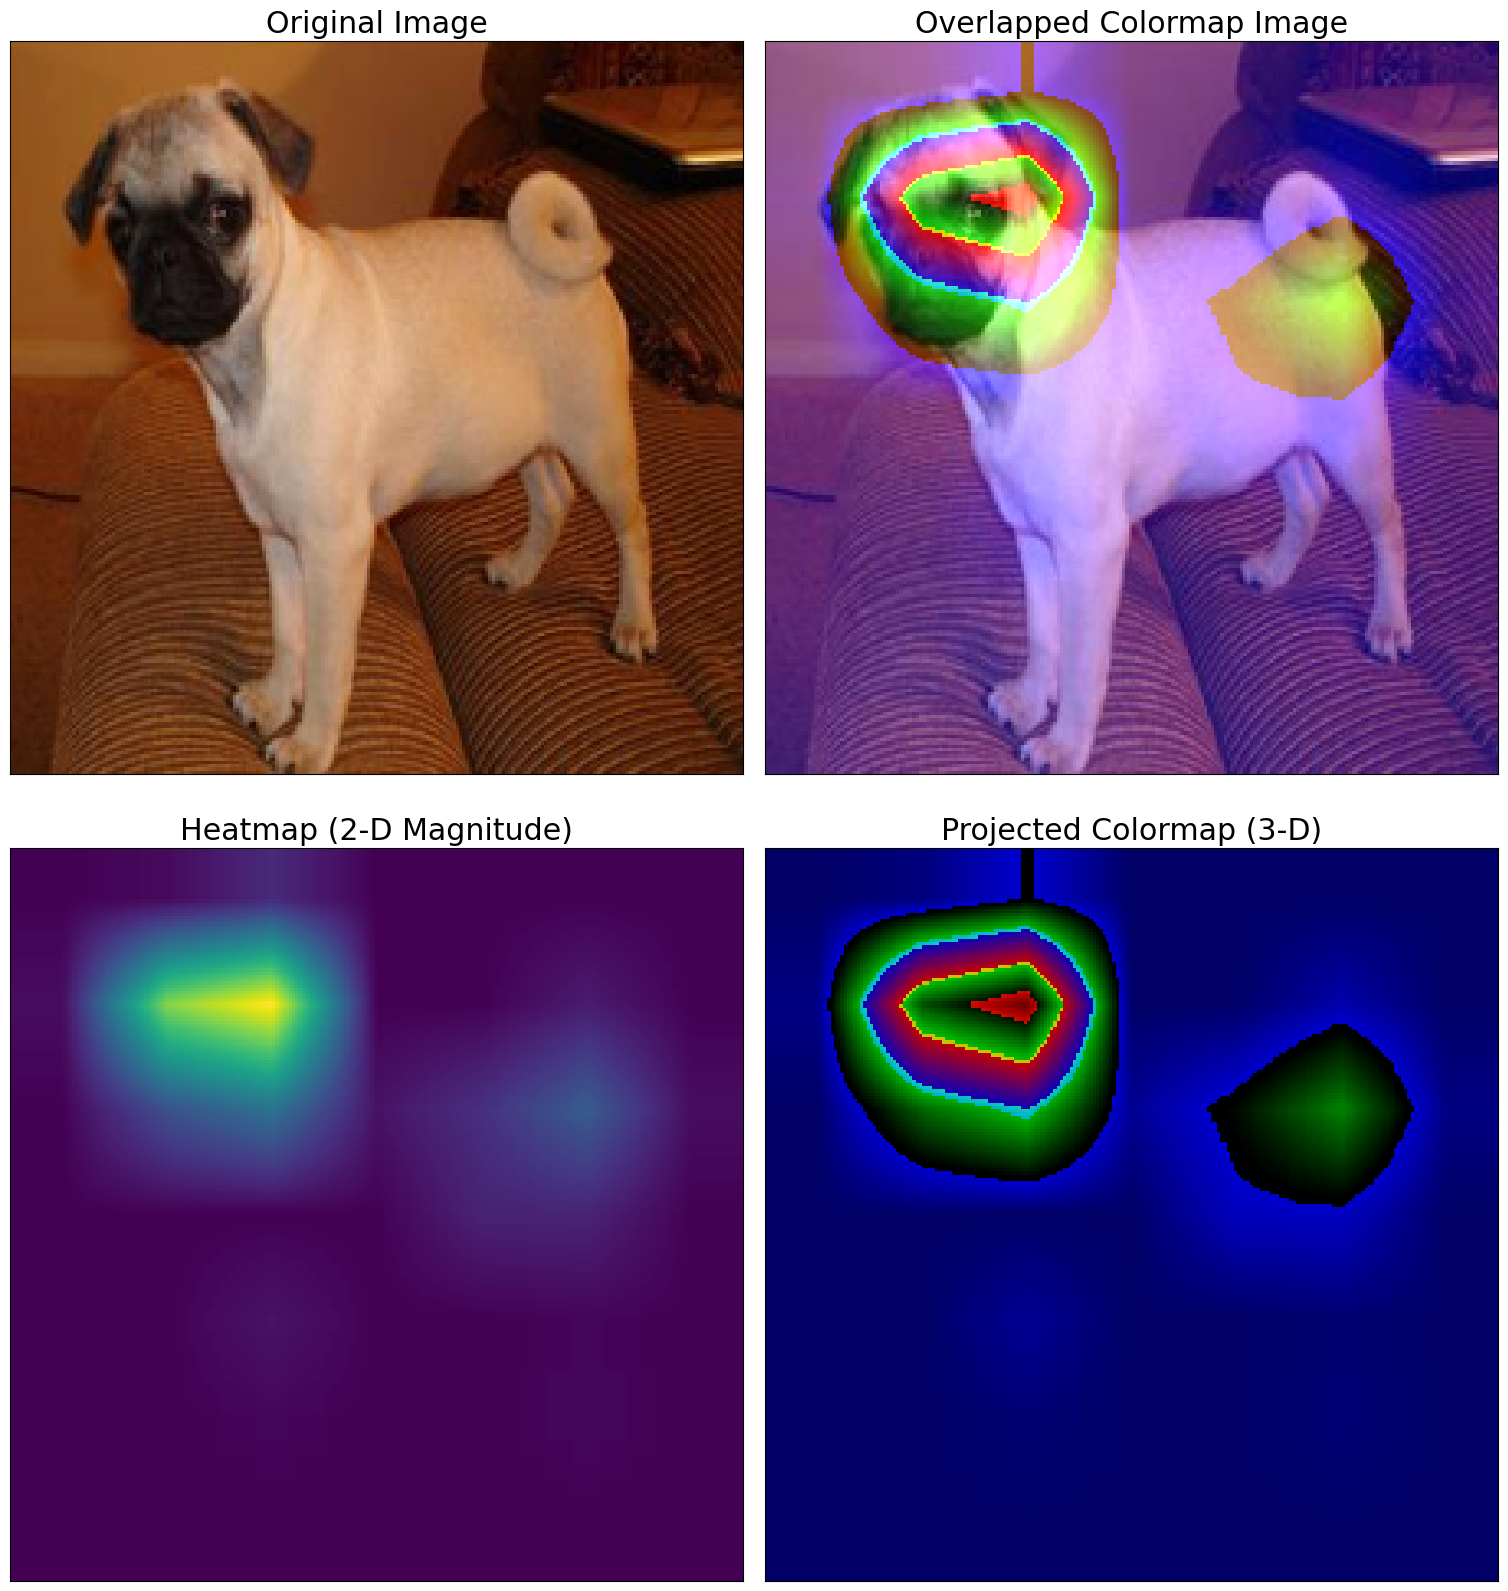

In [1]:
from grad_cam_code.grad_cam import *

#model = create_model('timm/resnet34.a1_in1k', pretrained=True)
model = create_model('timm/resnet18.a1_in1k', pretrained=True)
#model = create_model('timm/resnet10t.c3_in1k', pretrained=True)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'
#img_path = 'graphs/test_images/000000039769.jpg'

# use -1 will raise error since there's a pooling layer before classfication header in ResNet
cam = GradCAM(model,img_path,layer_idx=-2, model_type="Normal", ) 
cam(heatmap_threshold=100)
cam.imposing_visualization()
cam.heatmap


In [4]:
cam.transform

Compose(
    ToTensor()
)

### Vision Transformer (ViT) model example

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5887933].


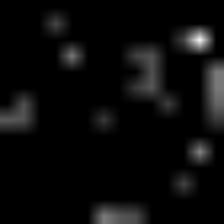

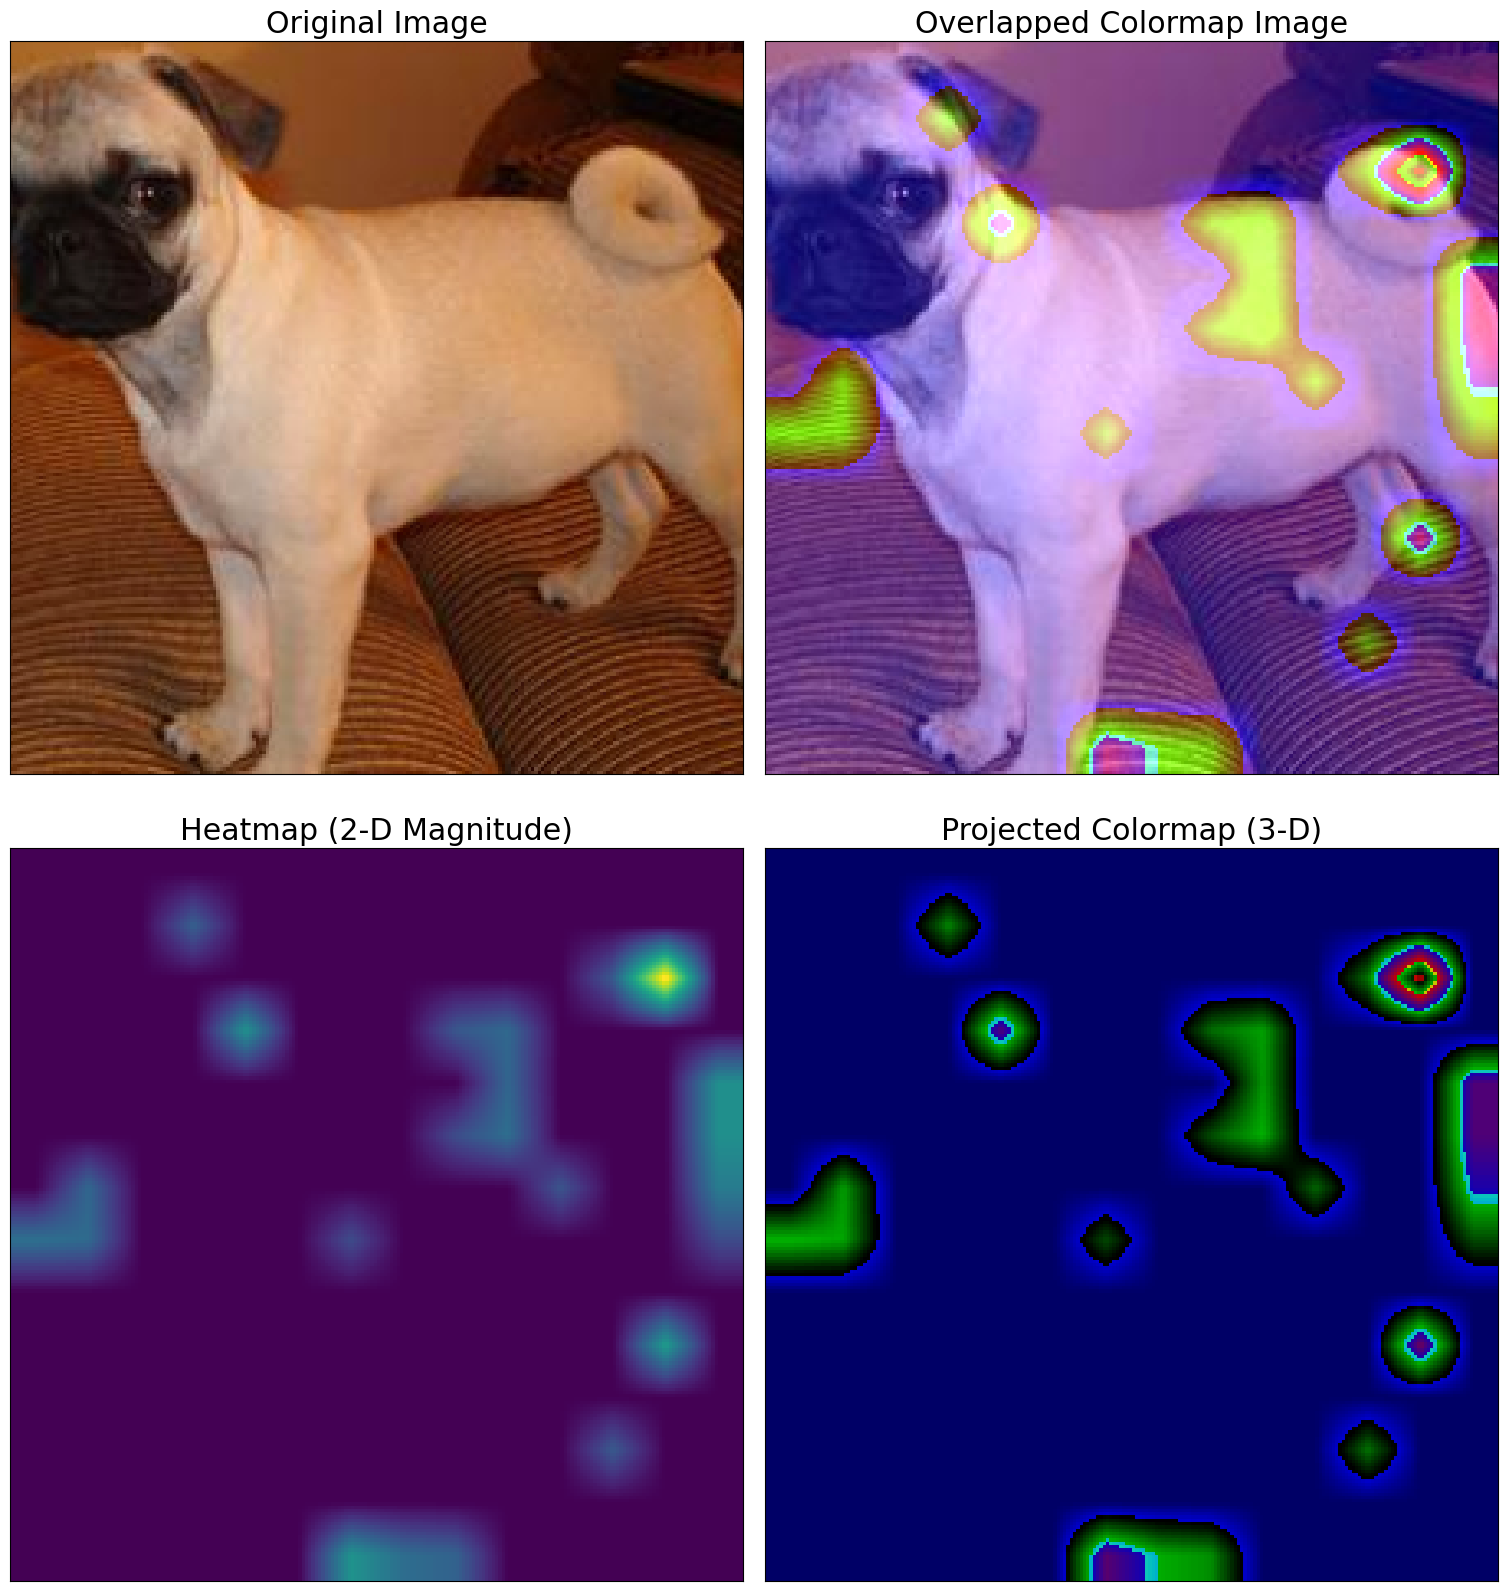

In [2]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config

model = create_model('vit_base_patch16_224', pretrained=True)
## Remember to pass the corresponding preprocessing method, if not using default.
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_idx=-1, model_type='ViT', transform = transform)
cam_vit(heatmap_threshold=5)
cam_vit.imposing_visualization()
cam_vit.heatmap


## Swin Transformer

Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.7418136649970393e-09..1.654901955861671].


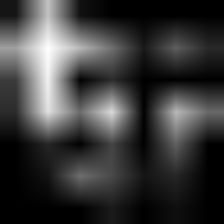

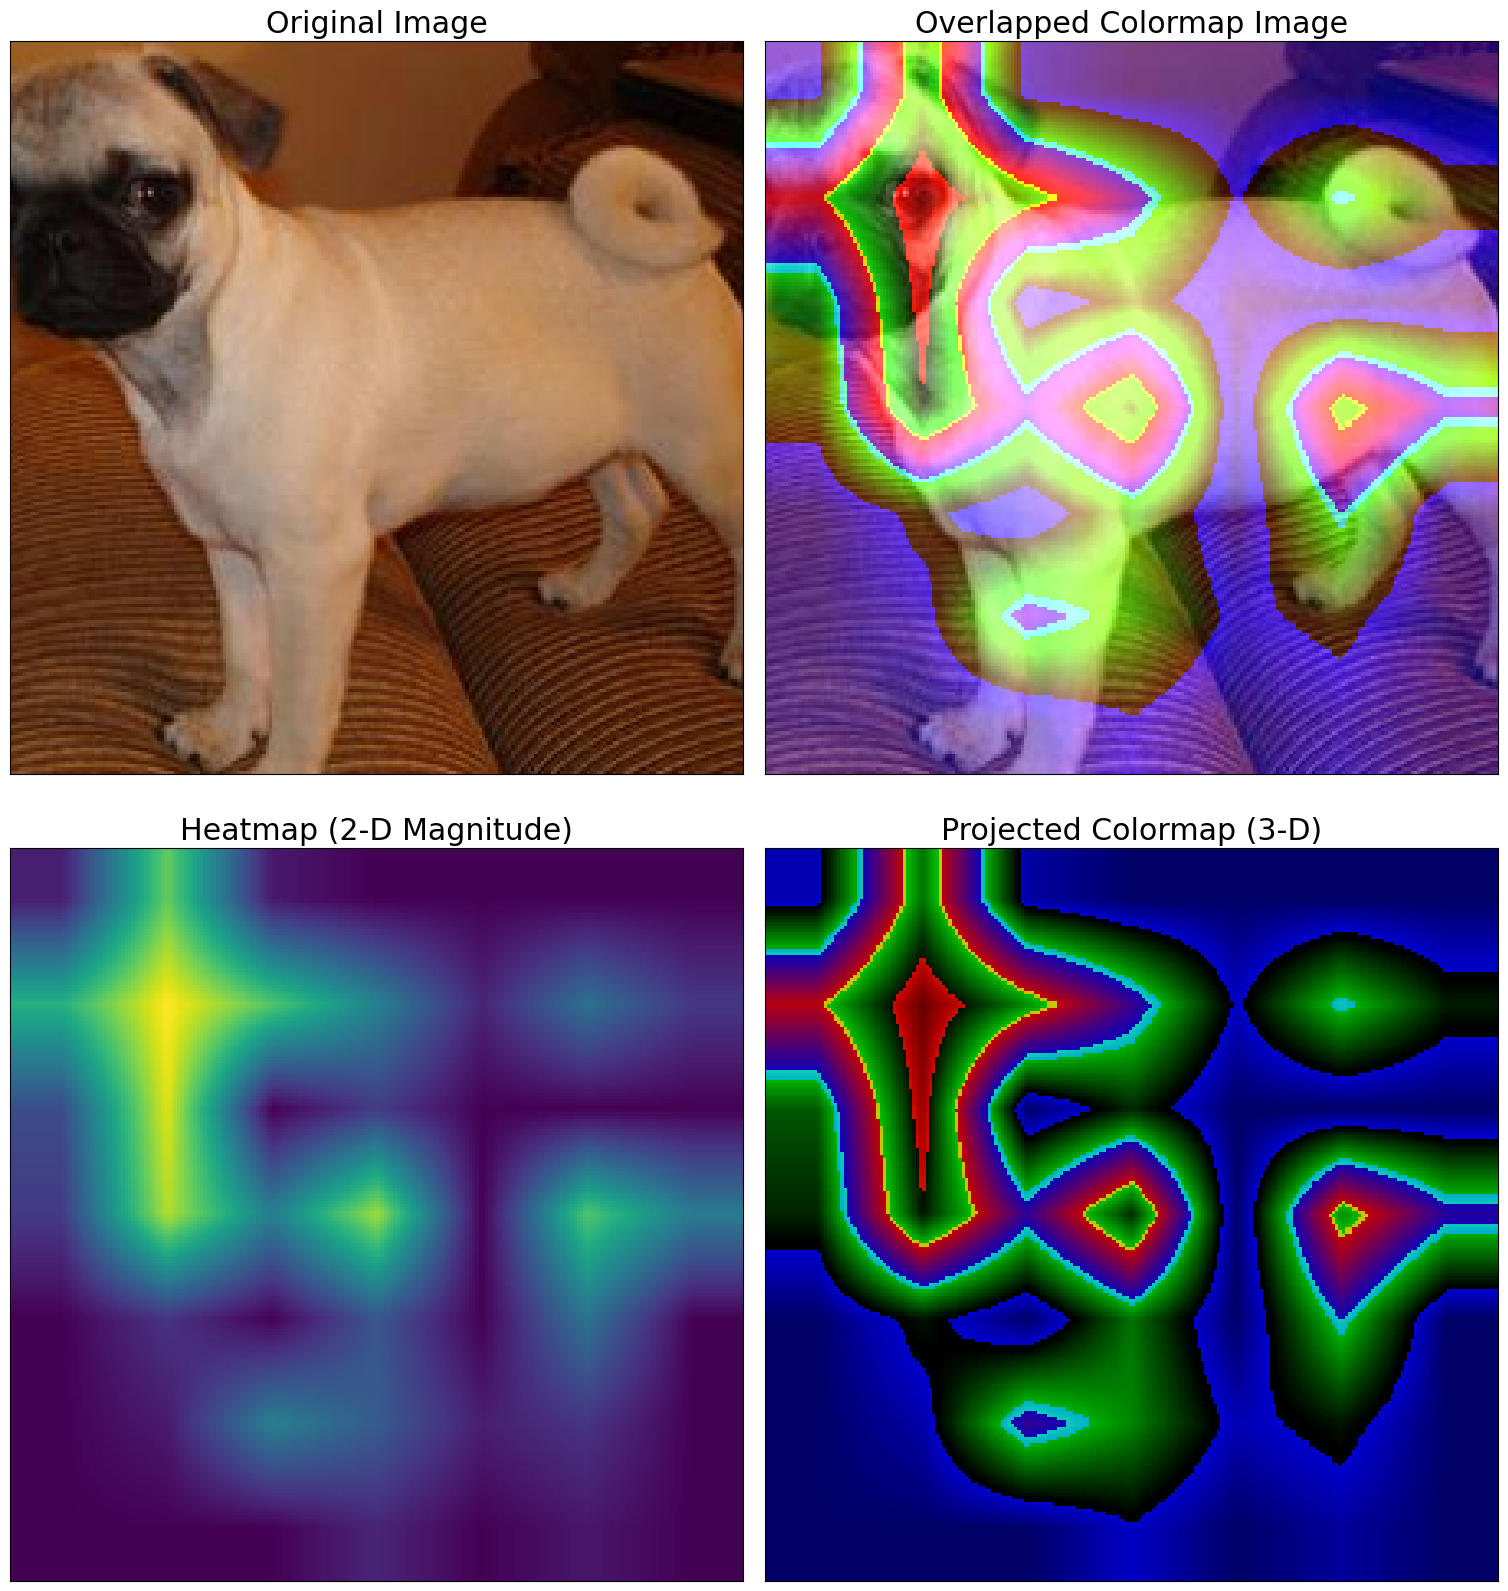

In [6]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config


model = create_model('swin_base_patch4_window7_224', pretrained=True)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
print(transform)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam = GradCAM(model,img_path,layer_idx=-1, model_type='SwinT', auto_find_classfier=True, transform = transform)
cam(heatmap_threshold=20)
cam.imposing_visualization(save_path="img/swt_test", denormalize=([0.4850, 0.4560, 0.4060],[0.2290, 0.2240, 0.2250]))    #specify the normalization method if not using the default when saving the images
cam.heatmap
